# Student Mental Health and Academic Behavior Analysis
### Exploratory Data Analysis and Machine Learning

In [1]:
## Import Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Load Dataset

In [5]:
data = pd.read_csv("college_students_habits_1M.csv")
data.head()

,study_hours,attendance,assignment_completion,midterm_score,final_score,project_score,backlogs,sleep_hours,stress,anxiety,...,hostel_student,extracurricular_hours,phone_unlocks_per_day,previous_gpa,class_participation,weekly_study_sessions,group_study_hours,financial_stress,gpa,performance_level
0,3.014684,67.00599,51.595387,57.211285,61.653540,65.397200,4,5.993893,4.287966,58.146000,...,0,1.958940,73.727480,5.721128,3.587111,2.814086,1.814086,5.491878,0.546729,Low
1,3.665277,73.28455,69.749020,57.552320,62.062782,65.715500,3,6.949383,1.841224,41.945290,...,0,3.146447,48.468456,5.755232,4.820090,2.836821,1.836821,2.876881,0.707133,Low
2,2.703784,72.32519,92.837640,44.568970,46.482760,53.597702,2,6.703293,3.863112,56.555750,...,1,5.551245,46.623684,4.456897,5.493774,1.971265,0.971265,5.704047,0.868230,Low
3,3.445073,74.75687,85.189026,52.040790,55.448948,60.571404,2,6.498832,5.073206,65.171420,...,1,4.543216,47.909600,5.204079,5.481987,2.469386,1.469386,6.596658,0.729216,Low
4,0.192687,55.05021,64.520620,32.815000,32.378000,42.627330,5,6.552570,1.000000,30.725826,...,1,4.447042,73.316520,3.281500,2.822375,1.187667,0.187667,4.602954,0.370964,Low


## Dataset Overview

The dataset contains behavioral, academic, and psychological metrics for simulated college students.

Features include:
- Study habits
- Screen time
- Financial stress
- Academic performance
- Mental health indicators

In [6]:
data.shape
data.columns
data.describe()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 42 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   study_hours               1000000 non-null  float64
 1   attendance                1000000 non-null  float64
 2   assignment_completion     1000000 non-null  float64
 3   midterm_score             1000000 non-null  float64
 4   final_score               1000000 non-null  float64
 5   project_score             1000000 non-null  float64
 6   backlogs                  1000000 non-null  int64  
 7   sleep_hours               1000000 non-null  float64
 8   stress                    1000000 non-null  float64
 9   anxiety                   1000000 non-null  float64
 10  depression                1000000 non-null  float64
 11  motivation                1000000 non-null  float64
 12  concentration             1000000 non-null  float64
 13  time_management           10

## Dataset Structure

The dataset contains 1,000,000 student records and 42 variables of academic performance, behavioral habits, and psychological indicators.

Most of the variables are numeric (float or integer), which makes them suitable for statistical analysis and machine learning models. One column, `performance_level`, is categorical and stored as an object datatype.

Nearly all variables contain complete data with no missing values. The `performance_level` column contains a small number of missing entries that may require cleaning during later analysis.

The dataset has about 320 MB of memory, as it is a large scale dataset used in this analysis.

## Missing Values

A check for missing values shows that nearly all variables in the dataset are complete.
Only the 'performance-level' column contains entries, with 1,558 null values out of 1,000,000 total records (~0.15%)
Because the percentage of missing values is very small, this column can either be cleaned by removing these rows or by imputing the missing values if needed for modeling

In [7]:
data.isnull().sum()

study_hours                    0
attendance                     0
assignment_completion          0
midterm_score                  0
final_score                    0
project_score                  0
backlogs                       0
sleep_hours                    0
stress                         0
anxiety                        0
depression                     0
motivation                     0
concentration                  0
time_management                0
self_discipline                0
social_media_hours             0
gaming_hours                   0
netflix_hours                  0
screen_time                    0
physical_activity              0
junk_food_frequency            0
caffeine_mg                    0
late_night_frequency           0
procrastination_score          0
family_income                  0
parental_education_level       0
internet_quality               0
library_visits                 0
online_courses_completed       0
part_time_hours                0
peer_study

## Studying and Final Scores
the analysis below shows a strong correlation between studying and its affects on final scores. this suggests higher study times contribute to higher academic performance

In [8]:
data[["study_hours","final_score"]].corr()

,study_hours,final_score
study_hours,1.00000,0.97294
final_score,0.97294,1.00000


Text(0.5, 1.0, 'How Study Hours affect Final Scores')

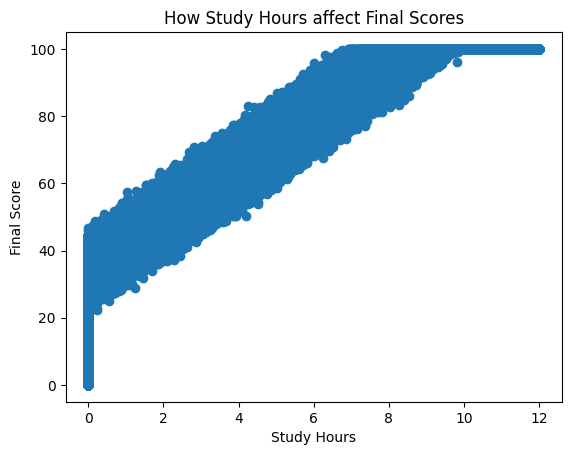

In [9]:
plt.scatter(data["study_hours"], data["final_score"])
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("How Study Hours affect Final Scores")

## Correlation Heatmap

This heatmap shows how strong each variable correlates to the other. Red indicates strong positive correlation between variables, while blue indicates strong negative correlation. Lighter colors represent weaker or no correlation.  For instance, the heatmap shows a strong correlation between gaming hours and junk food intake. A cluster of strong correlations appears among academic behavior variables such as study hours, concentration, and assignment completion. These variables also show strong positive relationships with final scores, suggesting they are key predictors of academic performance. Another visible cluster appears among lifestyle variables such as gaming hours, screen time, social media usage, and late-night activity, suggesting these behaviors often occur together.

<Axes: >

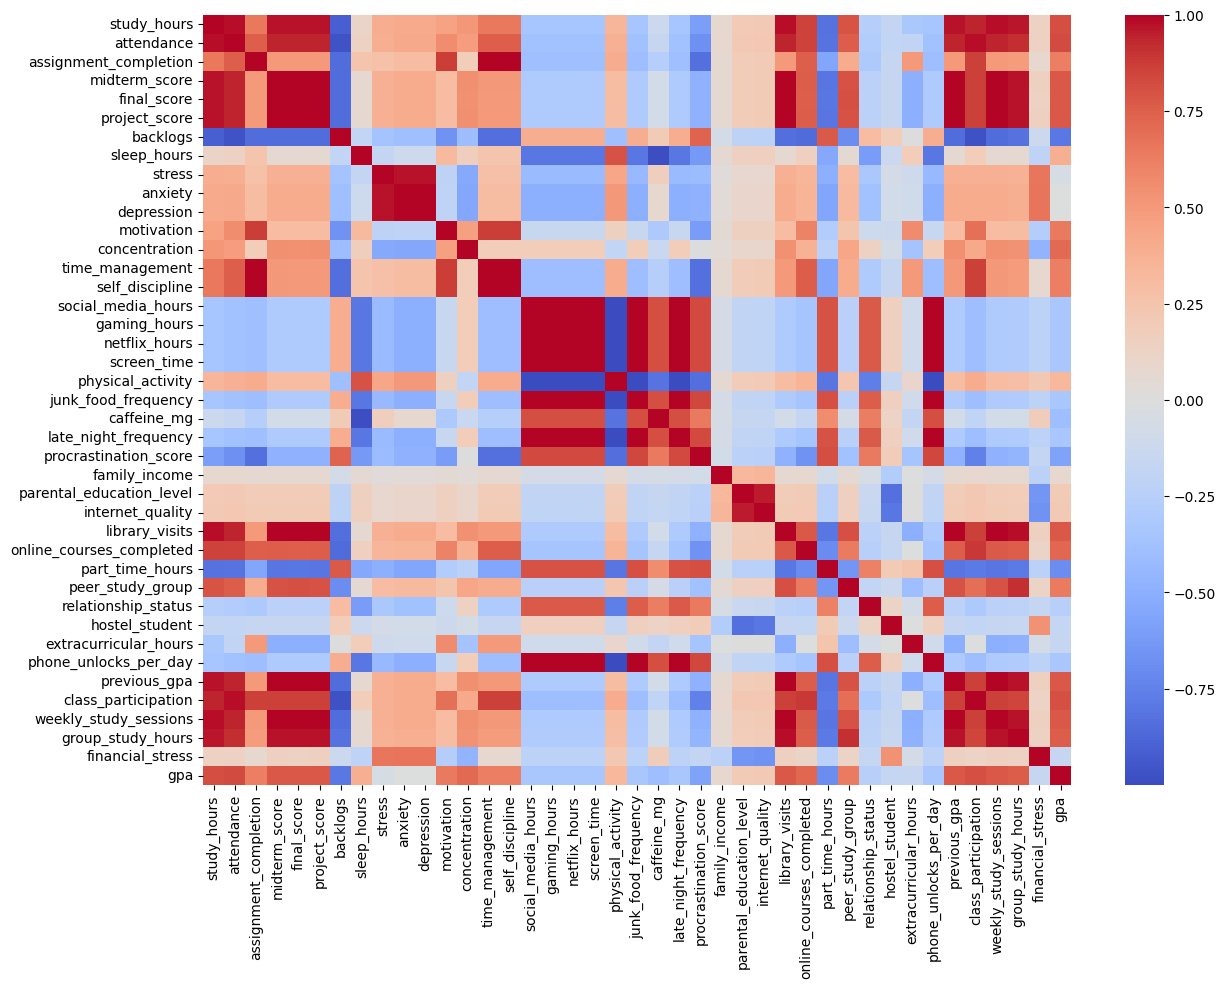

In [10]:
plt.figure(figsize=(14,10))
sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm")

## Using a Predictive Model 

A linear regression model was trained to predict student depression scores based on behavioral, academic, and lifestyle variables in the dataset.

The scatter plot above compares the model’s predicted depression scores with the actual values from the test dataset.

The points form a nearly perfect diagonal line, indicating that the model’s predictions closely match the actual depression scores. This result is consistent with the model’s R² score of approximately 0.9999, which suggests that the model explains nearly all of the variance in depression scores within the dataset.

Overall, the model demonstrates extremely strong predictive performance for this simulated dataset. Because the dataset is simulated, the relationships between variables may be cleaner than what would typically appear in real-world behavioral datasets.

In [11]:
X = data.drop(columns=["depression"])
X = X.select_dtypes(include="number")
y = data["depression"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
predictions = model.predict(X_test)

In [15]:
r2 = r2_score(y_test, predictions)
print("Model R2 score:", r2)

Model R2 score: 0.9999060708407531


<function matplotlib.pyplot.show(close=None, block=None)>

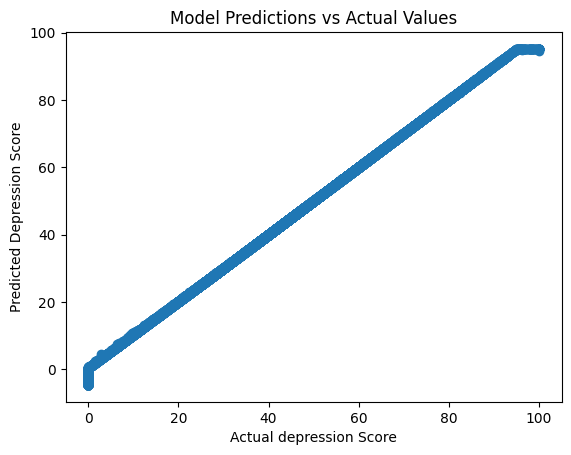

In [16]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual depression Score")
plt.ylabel("Predicted Depression Score")
plt.title("Model Predictions vs Actual Values")

plt.show

## Residual Analysis

Residuals represent the difference between the actual depression scores and the model's predicted values.

The residual plot shows the distribution of prediction errors across the model's predictions. Ideally, residuals should be randomly distributed around zero, indicating that the model's errors are small and unbiased.

In this case, the residuals are very close to zero for most observations, which supports the extremely high R² score observed earlier. This suggests that the linear regression model is able to predict depression scores with very high accuracy in this simulated dataset.

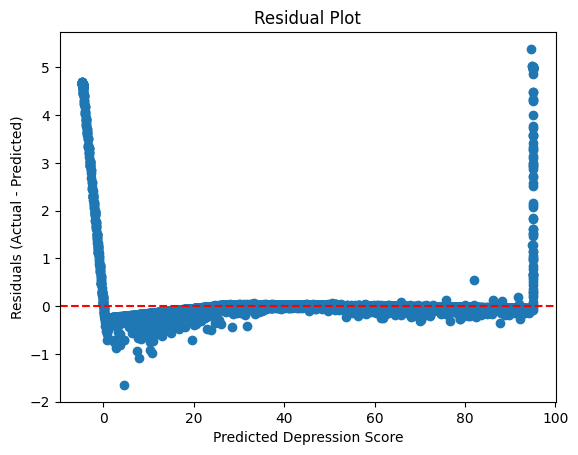

In [17]:
residuals = y_test - predictions

plt.scatter(predictions, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Depression Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

## Conclusion

This analysis suggests that academic habits and lifestyle patterns are strongly associated with both academic performance and mental health outcomes.

Study behaviors such as study hours, concentration, and assignment completion show strong relationships with GPA and final scores. Lifestyle behaviors such as gaming, screen time, and late-night activity appear to cluster together.

Financial stress and psychological indicators such as anxiety and stress show measurable relationships with depression scores.

The linear regression model achieved extremely high predictive performance (R² ≈ 0.9999), indicating that the selected features strongly explain variation in depression scores within this simulated dataset.

Residuals are generally close to zero across most predicted values, indicating small prediction errors. Some larger deviations appear at the extreme ends of the prediction range, but overall the model demonstrates very strong predictive accuracy.

Future analysis could explore more complex models and investigate potential causal relationships between lifestyle behaviors, academic performance, and mental health outcomes.

Because this dataset is simulated, some variables may be strongly constructed to relate to depression scores, which may explain the extremely high predictive performance of the model.